In [1]:
%matplotlib inline
import numpy as np #numpy is use for numeric term
import pandas as pd #pandas is use for data  manupulation data ko clean karna filling data
from datetime import timedelta #it is use for acceses date and time
import datetime as dt#it is use for acceses date and time
import matplotlib.pyplot as plt # represent graph
import seaborn as sns # seborn is use for graph
from sklearn.model_selection import train_test_split 
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd 
url = "https://raw.githubusercontent.com/guebin/DV2023/main/posts/NYCTaxi.csv" 
df = pd.read_csv(url)
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id3194108,1,2016-06-01 11:48:41,2016-06-01 12:19:07,1,-74.005028,40.746452,-73.972008,40.745781,N,1826
2,id3564028,1,2016-01-02 01:16:42,2016-01-02 01:19:56,1,-73.954132,40.774784,-73.947418,40.779633,N,194
3,id1660823,2,2016-03-01 06:40:18,2016-03-01 07:01:37,5,-73.982140,40.775326,-74.009850,40.721699,N,1279
4,id1575277,2,2016-06-11 16:59:15,2016-06-11 17:33:27,1,-73.999229,40.722881,-73.982880,40.778297,N,2052


In [3]:
df.shape

(14587, 11)

In [4]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14587 entries, 0 to 14586
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  14587 non-null  object 
 1   vendor_id           14587 non-null  int64  
 2   pickup_datetime     14587 non-null  object 
 3   dropoff_datetime    14587 non-null  object 
 4   passenger_count     14587 non-null  int64  
 5   pickup_longitude    14587 non-null  float64
 6   pickup_latitude     14587 non-null  float64
 7   dropoff_longitude   14587 non-null  float64
 8   dropoff_latitude    14587 non-null  float64
 9   store_and_fwd_flag  14587 non-null  object 
 10  trip_duration       14587 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 1.2+ MB


In [6]:
np.sum(pd.isnull(df))

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [7]:
df['pickup_datetime'] = pd.to_datetime(df.pickup_datetime) 
df['dropoff_datetime'] = pd.to_datetime(df.dropoff_datetime)

In [8]:
df[['pickup_datetime', 'dropoff_datetime']].head()

,pickup_datetime,dropoff_datetime
0,2016-03-14 17:24:55,2016-03-14 17:32:30
1,2016-06-01 11:48:41,2016-06-01 12:19:07
2,2016-01-02 01:16:42,2016-01-02 01:19:56
3,2016-03-01 06:40:18,2016-03-01 07:01:37
4,2016-06-11 16:59:15,2016-06-11 17:33:27


In [9]:
df.dtypes

id                            object
vendor_id                      int64
pickup_datetime       datetime64[ns]
dropoff_datetime      datetime64[ns]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
dtype: object

In [10]:
df['store_and_fwd_flag'] = 1 * (df.store_and_fwd_flag.values == 'Y')

In [11]:
df['check_trip_duration'] = ( df['dropoff_datetime']-
 df['pickup_datetime'] ).map(lambda x: x.total_seconds())

In [12]:
duration_difference = df[ np.abs( df['check_trip_duration'].values-
df['trip_duration'].values )>1
]

In [13]:
duration_difference.shape

(0, 12)

In [14]:
df['trip_duration'].describe()

count    14587.000000
mean       959.609721
std       3253.981823
min          2.000000
25%        398.500000
50%        666.000000
75%       1078.500000
max      86346.000000
Name: trip_duration, dtype: float64

In [15]:
df['trip_duration'].describe()/3600

count     4.051944
mean      0.266558
std       0.903884
min       0.000556
25%       0.110694
50%       0.185000
75%       0.299583
max      23.985000
Name: trip_duration, dtype: float64

In [21]:
df['log_trip_duration'] = np.log(df['trip_duration'].values+1)

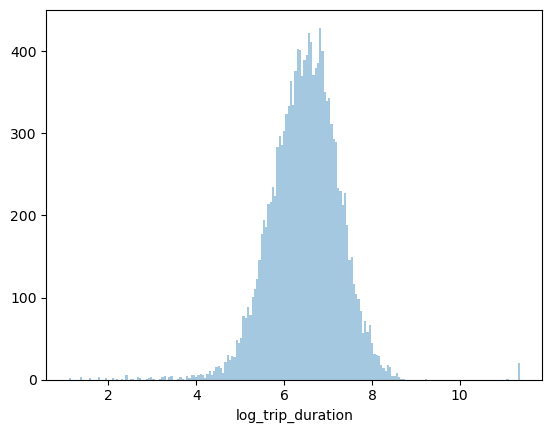

In [24]:
sns.distplot(df['log_trip_duration'],kde= 
             False,bins=200)
plt.show()

In [ ]:
__+++++